In [2]:
import numpy as np
import pandas as pd


In [5]:
df=pd.read_csv('spam.csv', encoding='latin1')

In [8]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
543,ham,4 oclock at mine. Just to bash out a flat plan.,NaN,NaN,NaN
733,ham,Even u dont get in trouble while convincing..j...,NaN,NaN,NaN
2385,spam,Someone has contacted our dating service and e...,NaN,NaN,NaN
5447,ham,So that takes away some money worries,NaN,NaN,NaN
382,ham,Hey leave it. not a big deal:-) take care.,NaN,NaN,NaN


In [11]:
df.shape

(5572, 5)

In [13]:
##data cleaning


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [15]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [16]:
df.sample(5)

,v1,v2
4583,ham,Noooooooo please. Last thing I need is stress....
1333,ham,"Oh... Icic... K lor, den meet other day..."
3757,ham,Lol no ouch but wish i'd stayed out a bit longer
946,spam,Ur cash-balance is currently 500 pounds - to m...
1934,ham,Hope you are having a great day.


In [ ]:
##rename the coloumn

In [18]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [20]:
df.sample(6)

,target,text
3192,ham,I will lick up every drop :) are you ready to ...
5331,ham,X course it 2yrs. Just so her messages on mess...
356,spam,Congratulations ur awarded 500 of CD vouchers ...
1830,ham,That's the way you should stay oh.
2190,ham,"Ooh, 4got, i'm gonna start belly dancing in mo..."
2570,ham,From 5 to 2 only my work timing.


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [22]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [23]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
df.isnull().sum()

,0
target,0
text,0


In [ ]:
##checking duplicate values

In [25]:
df.duplicated().sum()

np.int64(403)

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
df.shape

(5169, 2)

In [28]:
df.duplicated().sum()

np.int64(0)

In [ ]:
## EDA

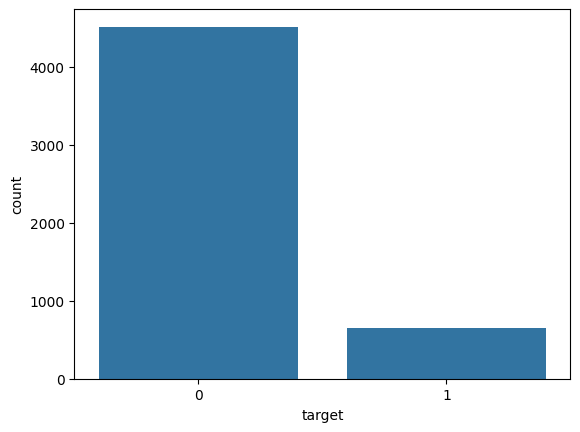

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.show()


In [31]:
df['char_count'] = df['text'].apply(len)

In [32]:
df.head()


,target,text,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [33]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

In [35]:
df.head()


,target,text,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [41]:
from collections import Counter

spam_words = " ".join(df[df['target']==1]['text']).split()
Counter(spam_words).most_common(10)

[('to', 522),
 ('a', 314),
 ('your', 171),
 ('call', 163),
 ('the', 160),
 ('or', 155),
 ('for', 152),
 ('2', 151),
 ('you', 150),
 ('is', 130)]

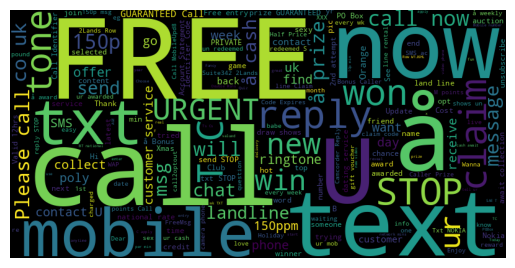

In [43]:
from wordcloud import WordCloud

spam_text = " ".join(df[df['target']==1]['text'])

wc = WordCloud(width=800,height=400).generate(spam_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [45]:
df.duplicated().sum()


np.int64(0)

In [45]:
##data preprocessing

In [46]:
df['text'] = df['text'].str.lower()


In [47]:
df.head()

,target,text,char_count,word_count
0,0,"go until jurong point, crazy.. available only ...",111,20
1,0,ok lar... joking wif u oni...,29,6
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,28
3,0,u dun say so early hor... u c already then say...,49,11
4,0,"nah i don't think he goes to usf, he lives aro...",61,13


In [49]:
import string

df['text'] = df['text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))


In [51]:
import re

df['text'] = df['text'].apply(lambda x: re.sub(r'\d+', '', x))


In [53]:
df['text'] = df['text'].apply(lambda x: x.split())


In [56]:
 import nltk
 nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [57]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['text'] = df['text'].apply(
    lambda x: [word for word in x if word not in stop_words]
)


In [59]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

df['text'] = df['text'].apply(
    lambda x: [ps.stem(word) for word in x]
)


In [60]:
df.head()

,target,text,char_count,word_count
0,0,"[go, jurong, point, crazi, avail, bugi, n, gre...",111,20
1,0,"[ok, lar, joke, wif, u, oni]",29,6
2,1,"[free, entri, wkli, comp, win, fa, cup, final,...",155,28
3,0,"[u, dun, say, earli, hor, u, c, alreadi, say]",49,11
4,0,"[nah, dont, think, goe, usf, live, around, tho...",61,13


In [62]:
df['text'] = df['text'].apply(lambda x: " ".join(x))


In [64]:
##using the vectorising tchnique to convet the message to numbers/vectors

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['text'])


In [68]:
X.shape

(5169, 7111)

In [70]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 41419 stored elements and shape (5169, 7111)>
  Coords	Values
  (0, 2346)	0.14011614238342635
  (0, 3118)	0.3499201306086827
  (0, 4597)	0.23917168483433615
  (0, 1275)	0.2703201692797964
  (0, 402)	0.2703201692797964
  (0, 786)	0.29515373420619057
  (0, 2436)	0.19657660734136945
  (0, 6847)	0.2470993019135587
  (0, 3254)	0.2863383133773404
  (0, 784)	0.3339019865111387
  (0, 1057)	0.29515373420619057
  (0, 2399)	0.16386729427872676
  (0, 210)	0.3499201306086827
  (0, 6640)	0.19459098318770626
  (1, 4218)	0.2860711595965379
  (1, 3286)	0.41773185167564447
  (1, 3084)	0.48339970754714073
  (1, 6757)	0.4418750202708029
  (1, 4248)	0.5610121041000327
  (2, 2166)	0.12145446190284653
  (2, 1823)	0.3778149754928269
  (2, 6806)	0.2072616410034852
  (2, 1153)	0.2072616410034852
  (2, 6770)	0.15602532600018487
  (2, 1942)	0.5065687482382774
  :	:
  (5165, 2346)	0.29566121390307176
  (5165, 2691)	0.37735591144016006
  (5165, 2155)	0.5

In [73]:
y=df['target'].values

In [74]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [75]:
from sklearn.model_selection import train_test_split
X_test,X_train,y_test,y_train=train_test_split(X,y,test_size=0.3,random_state=True)

In [76]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_score = nb.score(X_test, y_test)
print("Naive Bayes:", nb_score)


Naive Bayes: 0.9220563847429519


In [77]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_score = lr.score(X_test, y_test)
print("Logistic Regression:", lr_score)


Logistic Regression: 0.9273079049198453


In [78]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_score = svm.score(X_test, y_test)
print("SVM:", svm_score)


SVM: 0.9560530679933665


In [81]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", rf.score(X_test, y_test))



Accuracy: 0.9632393587617468
